# Exploratory Data Analysis (EDA)

## Objective

The objective of this exploratory data analysis (EDA) is to understand the structure, quality, and characteristics of the Kenya Crop Yield dataset before developing machine learning models. This includes examining the dataset dimensions, data types, missing values, summary statistics, distributions of variables, and relationships between crop yield and environmental factors. The insights obtained from this analysis will guide data preprocessing, feature engineering, and model selection.

In [45]:
# Import Libraries & Load Dataset

# Import required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots within the notebook
%matplotlib inline

# Set plot style
plt.style.use('ggplot')

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Load dataset
df = pd.read_csv("../Data/Raw_data/Kenya_Crop_Yield_Dataset.csv")

# Display the first five rows
df.head()

,County,Crop,Year,Area_ha,Production_tons,Yield_t_ha,NDVI,Rainfall_mm,Temperature_C,Elevation_m,Slope_Degrees,Soil_Moisture,Evapotranspiration_mm
0,Baringo,Beans,2019,21020,19977,0.95038059,0.5218,1194.1247,32.2339,1396.4230,9.0675,0.1890,707.8706
1,Bomet,Beans,2019,32273,42592,1.31974096,0.6909,1701.3963,28.1587,1905.3299,5.5580,0.3890,1123.7098
2,Bungoma,Beans,2019,78930,56775,0.719308248,0.6323,2009.6689,30.1118,1553.9248,4.2350,0.3689,938.2848
3,Busia,Beans,2019,21083,21412,1.01560499,0.6342,2262.5101,30.6340,1229.2644,3.5520,0.3591,829.6820
4,Homa Bay,Beans,2019,48558,29696,0.611557313,0.6445,1885.0167,31.0128,1337.6682,4.0555,0.3431,924.3744


## Dataset Overview

This section examines the structure of the dataset, including the number of observations, variables, data types, and summary statistics. It also checks for missing values and duplicate records before further analysis.

In [46]:
# Dataset overview

print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns\n")

print("Data Types")
display(df.dtypes)

print("\nMissing Values")
display(df.isnull().sum())

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

print("\nSummary Statistics")
display(df.describe())

Dataset Shape: 765 rows and 13 columns

Data Types


County                       str
Crop                         str
Year                       int64
Area_ha                    int64
Production_tons            int64
Yield_t_ha                   str
NDVI                     float64
Rainfall_mm              float64
Temperature_C            float64
Elevation_m              float64
Slope_Degrees            float64
Soil_Moisture            float64
Evapotranspiration_mm    float64
dtype: object


Missing Values


County                   0
Crop                     0
Year                     0
Area_ha                  0
Production_tons          0
Yield_t_ha               0
NDVI                     5
Rainfall_mm              5
Temperature_C            5
Elevation_m              5
Slope_Degrees            5
Soil_Moisture            5
Evapotranspiration_mm    5
dtype: int64


Duplicate Rows: 0

Summary Statistics


,Year,Area_ha,Production_tons,NDVI,Rainfall_mm,Temperature_C,Elevation_m,Slope_Degrees,Soil_Moisture,Evapotranspiration_mm
count,765.0000,765.0000,765.0000,760.0000,760.0000,760.0000,760.0000,760.0000,760.0000,760.0000
mean,2021.0000,22968.6732,46780.3229,0.5853,1439.2680,29.3510,1499.8519,6.0792,0.2969,861.7734
std,1.4151,31988.3904,85601.1392,0.1021,557.9715,3.3146,543.1669,2.3142,0.0768,219.5550
min,2019.0000,0.0000,0.0000,0.2484,260.9567,21.3275,16.2847,2.1349,0.1087,153.9554
25%,2020.0000,869.0000,2057.0000,0.5217,968.8335,26.8775,1247.5327,4.2475,0.2387,726.5147
50%,2021.0000,6680.0000,14069.0000,0.6088,1432.3484,29.2662,1463.8956,5.6067,0.3082,901.1841
75%,2022.0000,35005.0000,50853.0000,0.6592,1855.7976,31.7555,1905.1767,7.3885,0.3588,1030.4575
max,2023.0000,150726.0000,657091.0000,0.7606,3012.3126,42.1022,2607.0111,13.6676,0.4489,1323.1058


## Data Quality Assessment

This section converts the target variable to the correct data type and investigates records with missing environmental variables to determine the appropriate data cleaning strategy.

In [47]:
# Convert Yield to numeric
df["Yield_t_ha"] = pd.to_numeric(df["Yield_t_ha"], errors="coerce")

# Confirm data types
print("Updated Data Types")
display(df.dtypes)

# Display rows with missing values
print("Rows with Missing Values:")
display(df[df.isnull().any(axis=1)])

# Check if Yield has any missing values after conversion
print(f"Missing values in Yield_t_ha: {df['Yield_t_ha'].isnull().sum()}")

Updated Data Types


County                       str
Crop                         str
Year                       int64
Area_ha                    int64
Production_tons            int64
Yield_t_ha               float64
NDVI                     float64
Rainfall_mm              float64
Temperature_C            float64
Elevation_m              float64
Slope_Degrees            float64
Soil_Moisture            float64
Evapotranspiration_mm    float64
dtype: object

Rows with Missing Values:


,County,Crop,Year,Area_ha,Production_tons,Yield_t_ha,NDVI,Rainfall_mm,Temperature_C,Elevation_m,Slope_Degrees,Soil_Moisture,Evapotranspiration_mm
89,Lamu,Pigeon Peas,2019,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
241,Laikipia,Pigeon Peas,2020,0,35,NaN,0.5613,1049.1839,31.0218,1572.3059,8.5724,0.2640,763.0705
242,Lamu,Pigeon Peas,2020,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
394,Laikipia,Pigeon Peas,2021,0,28,NaN,0.3842,603.1207,35.7408,1572.3059,8.5724,0.2063,396.1240
395,Lamu,Pigeon Peas,2021,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
547,Laikipia,Pigeon Peas,2022,0,32,NaN,0.3483,518.3237,35.8988,1572.3059,8.5724,0.1865,377.4362
548,Lamu,Pigeon Peas,2022,530,318,0.6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
701,Lamu,Pigeon Peas,2023,500,300,0.6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values in Yield_t_ha: 6


## Data Cleaning

Records with missing target values or missing environmental variables were removed. These observations could not be used for modelling because the target yield could not be calculated or the predictor variables were unavailable.

In [48]:
# Remove rows with any missing values
df = df.dropna().reset_index(drop=True)

# Verify dataset after cleaning
print(f"New dataset shape: {df.shape}")

print("\nMissing values")
display(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Display first five rows
df.head()

New dataset shape: (757, 13)

Missing values


County                   0
Crop                     0
Year                     0
Area_ha                  0
Production_tons          0
Yield_t_ha               0
NDVI                     0
Rainfall_mm              0
Temperature_C            0
Elevation_m              0
Slope_Degrees            0
Soil_Moisture            0
Evapotranspiration_mm    0
dtype: int64


Duplicate rows: 0


,County,Crop,Year,Area_ha,Production_tons,Yield_t_ha,NDVI,Rainfall_mm,Temperature_C,Elevation_m,Slope_Degrees,Soil_Moisture,Evapotranspiration_mm
0,Baringo,Beans,2019,21020,19977,0.9504,0.5218,1194.1247,32.2339,1396.4230,9.0675,0.1890,707.8706
1,Bomet,Beans,2019,32273,42592,1.3197,0.6909,1701.3963,28.1587,1905.3299,5.5580,0.3890,1123.7098
2,Bungoma,Beans,2019,78930,56775,0.7193,0.6323,2009.6689,30.1118,1553.9248,4.2350,0.3689,938.2848
3,Busia,Beans,2019,21083,21412,1.0156,0.6342,2262.5101,30.6340,1229.2644,3.5520,0.3591,829.6820
4,Homa Bay,Beans,2019,48558,29696,0.6116,0.6445,1885.0167,31.0128,1337.6682,4.0555,0.3431,924.3744


## Distribution of Observations

This section examines how the observations are distributed across crops, counties, and years. Understanding the distribution helps identify whether the dataset is balanced and highlights any potential sampling bias that could influence model performance.

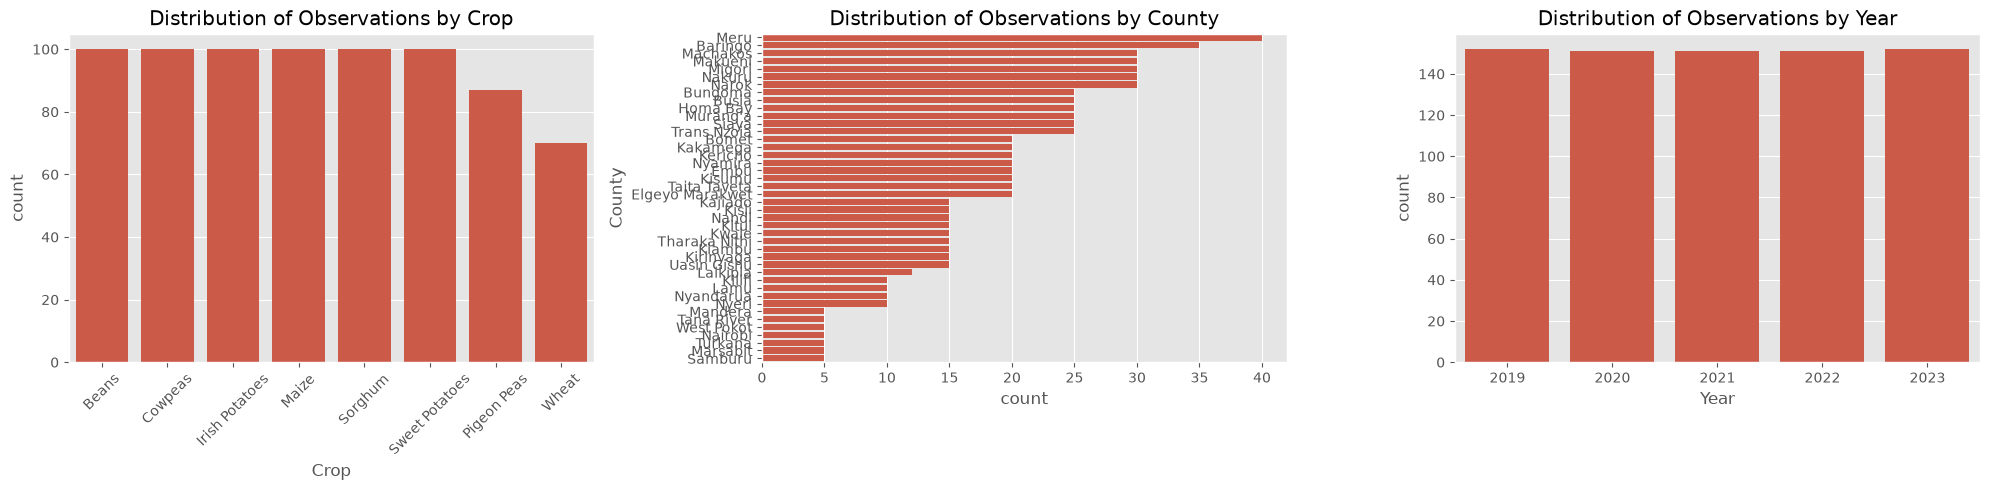

Crop Counts


Crop
Beans             100
Cowpeas           100
Irish Potatoes    100
Maize             100
Sorghum           100
Sweet Potatoes    100
Pigeon Peas        87
Wheat              70
Name: count, dtype: int64


County Counts


County
Meru               40
Baringo            35
Machakos           30
Makueni            30
Migori             30
Nakuru             30
Narok              30
Bungoma            25
Busia              25
Homa Bay           25
Murang'a           25
Siaya              25
Trans Nzoia        25
Bomet              20
Kakamega           20
Kericho            20
Nyamira            20
Embu               20
Kisumu             20
Taita Taveta       20
Elgeyo Marakwet    20
Kajiado            15
Kisii              15
Nandi              15
Kitui              15
Kwale              15
Tharaka Nithi      15
Kiambu             15
Kirinyaga          15
Uasin Gishu        15
Laikipia           12
Kilifi             10
Lamu               10
Nyandarua          10
Nyeri              10
Mandera             5
Tana River          5
West Pokot          5
Nairobi             5
Turkana             5
Marsabit            5
Samburu             5
Name: count, dtype: int64


Year Counts


Year
2019    152
2020    151
2021    151
2022    151
2023    152
Name: count, dtype: int64

In [49]:
# Distribution of observations

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Crop distribution
sns.countplot(
    data=df,
    x='Crop',
    order=df['Crop'].value_counts().index,
    ax=axes[0]
)
axes[0].set_title('Distribution of Observations by Crop')
axes[0].tick_params(axis='x', rotation=45)

# County distribution
sns.countplot(
    data=df,
    y='County',
    order=df['County'].value_counts().index,
    ax=axes[1]
)
axes[1].set_title('Distribution of Observations by County')

# Year distribution
sns.countplot(
    data=df,
    x='Year',
    order=sorted(df['Year'].unique()),
    ax=axes[2]
)
axes[2].set_title('Distribution of Observations by Year')

plt.tight_layout()

# Save figure
plt.savefig(
    "../figures/distribution_of_observations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Display frequency tables
print("Crop Counts")
display(df['Crop'].value_counts())

print("\nCounty Counts")
display(df['County'].value_counts())

print("\nYear Counts")
display(df['Year'].value_counts().sort_index())

### Distribution of Observations

The dataset contains 757 observations collected between 2019 and 2023 across eight major crops grown in Kenya.

Beans, Cowpeas, Irish Potatoes, Maize, Sorghum and Sweet Potatoes each contribute 100 observations, while Pigeon Peas (87) and Wheat (70) have fewer records because they are cultivated in fewer counties.
The distribution across years is nearly uniform, with approximately 151–152 observations per year, indicating good temporal balance.
County representation varies according to where each crop is grown. Meru has the highest number of observations (40), followed by Baringo (35), while counties such as Marsabit, Samburu, Turkana, Nairobi, Tana River and Mandera each contribute only five observations because fewer study crops are cultivated there.

Overall, the dataset is reasonably balanced across years and crops, although county representation differs based on crop distribution across Kenya.

## Distribution of Numerical Variables

This section examines the distribution of the numerical variables used in crop yield prediction. Histograms are used to visualize the frequency distribution of each variable, while boxplots help identify the spread of the data and the presence of potential outliers. Understanding these distributions is important for selecting appropriate preprocessing techniques and machine learning models.

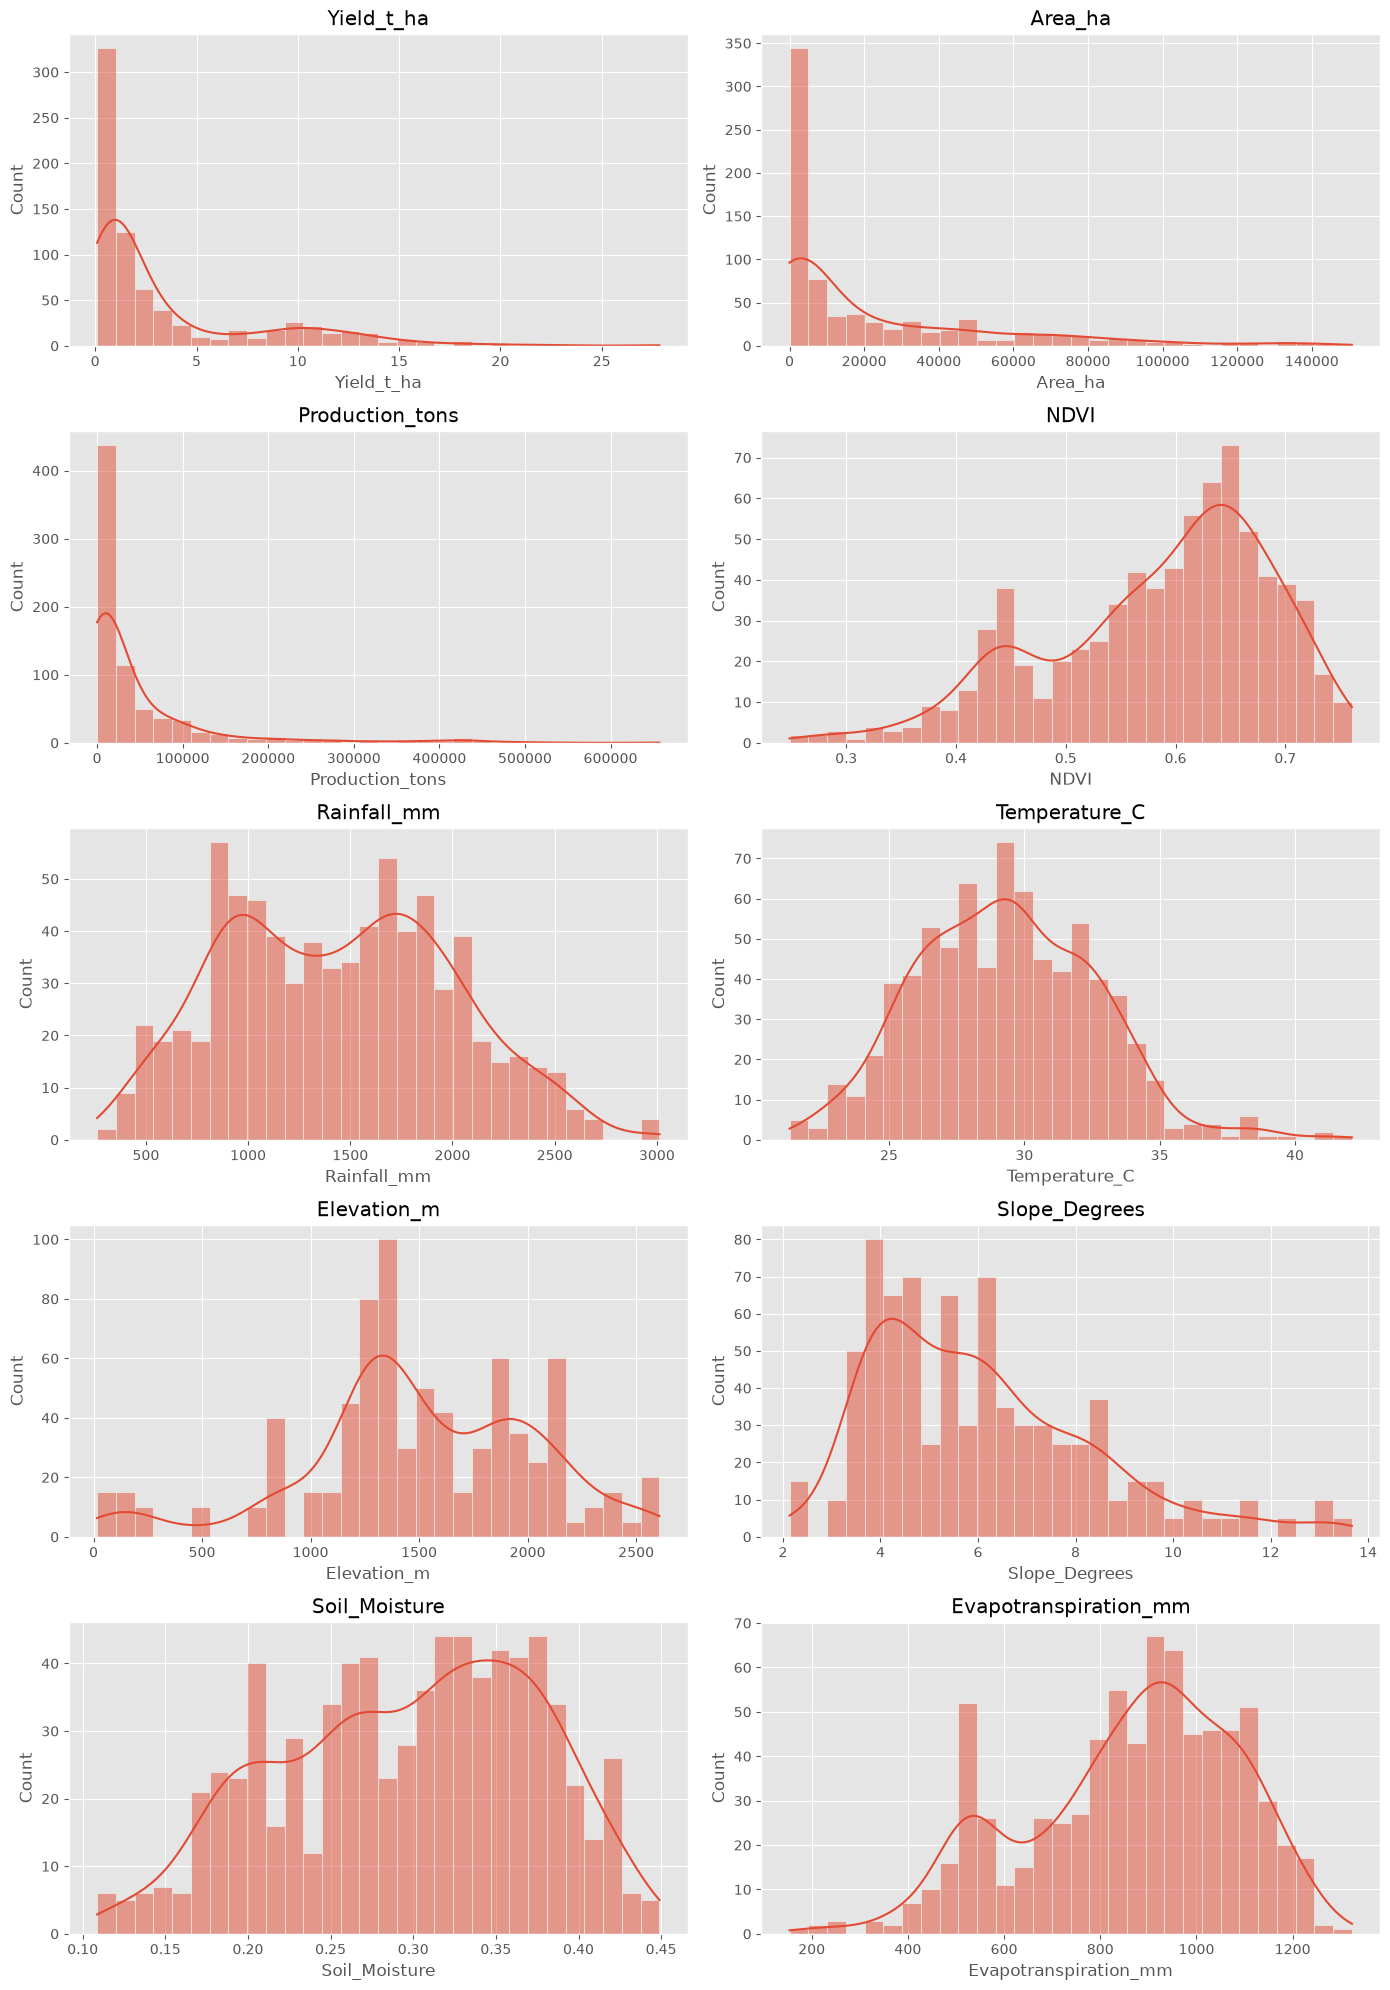

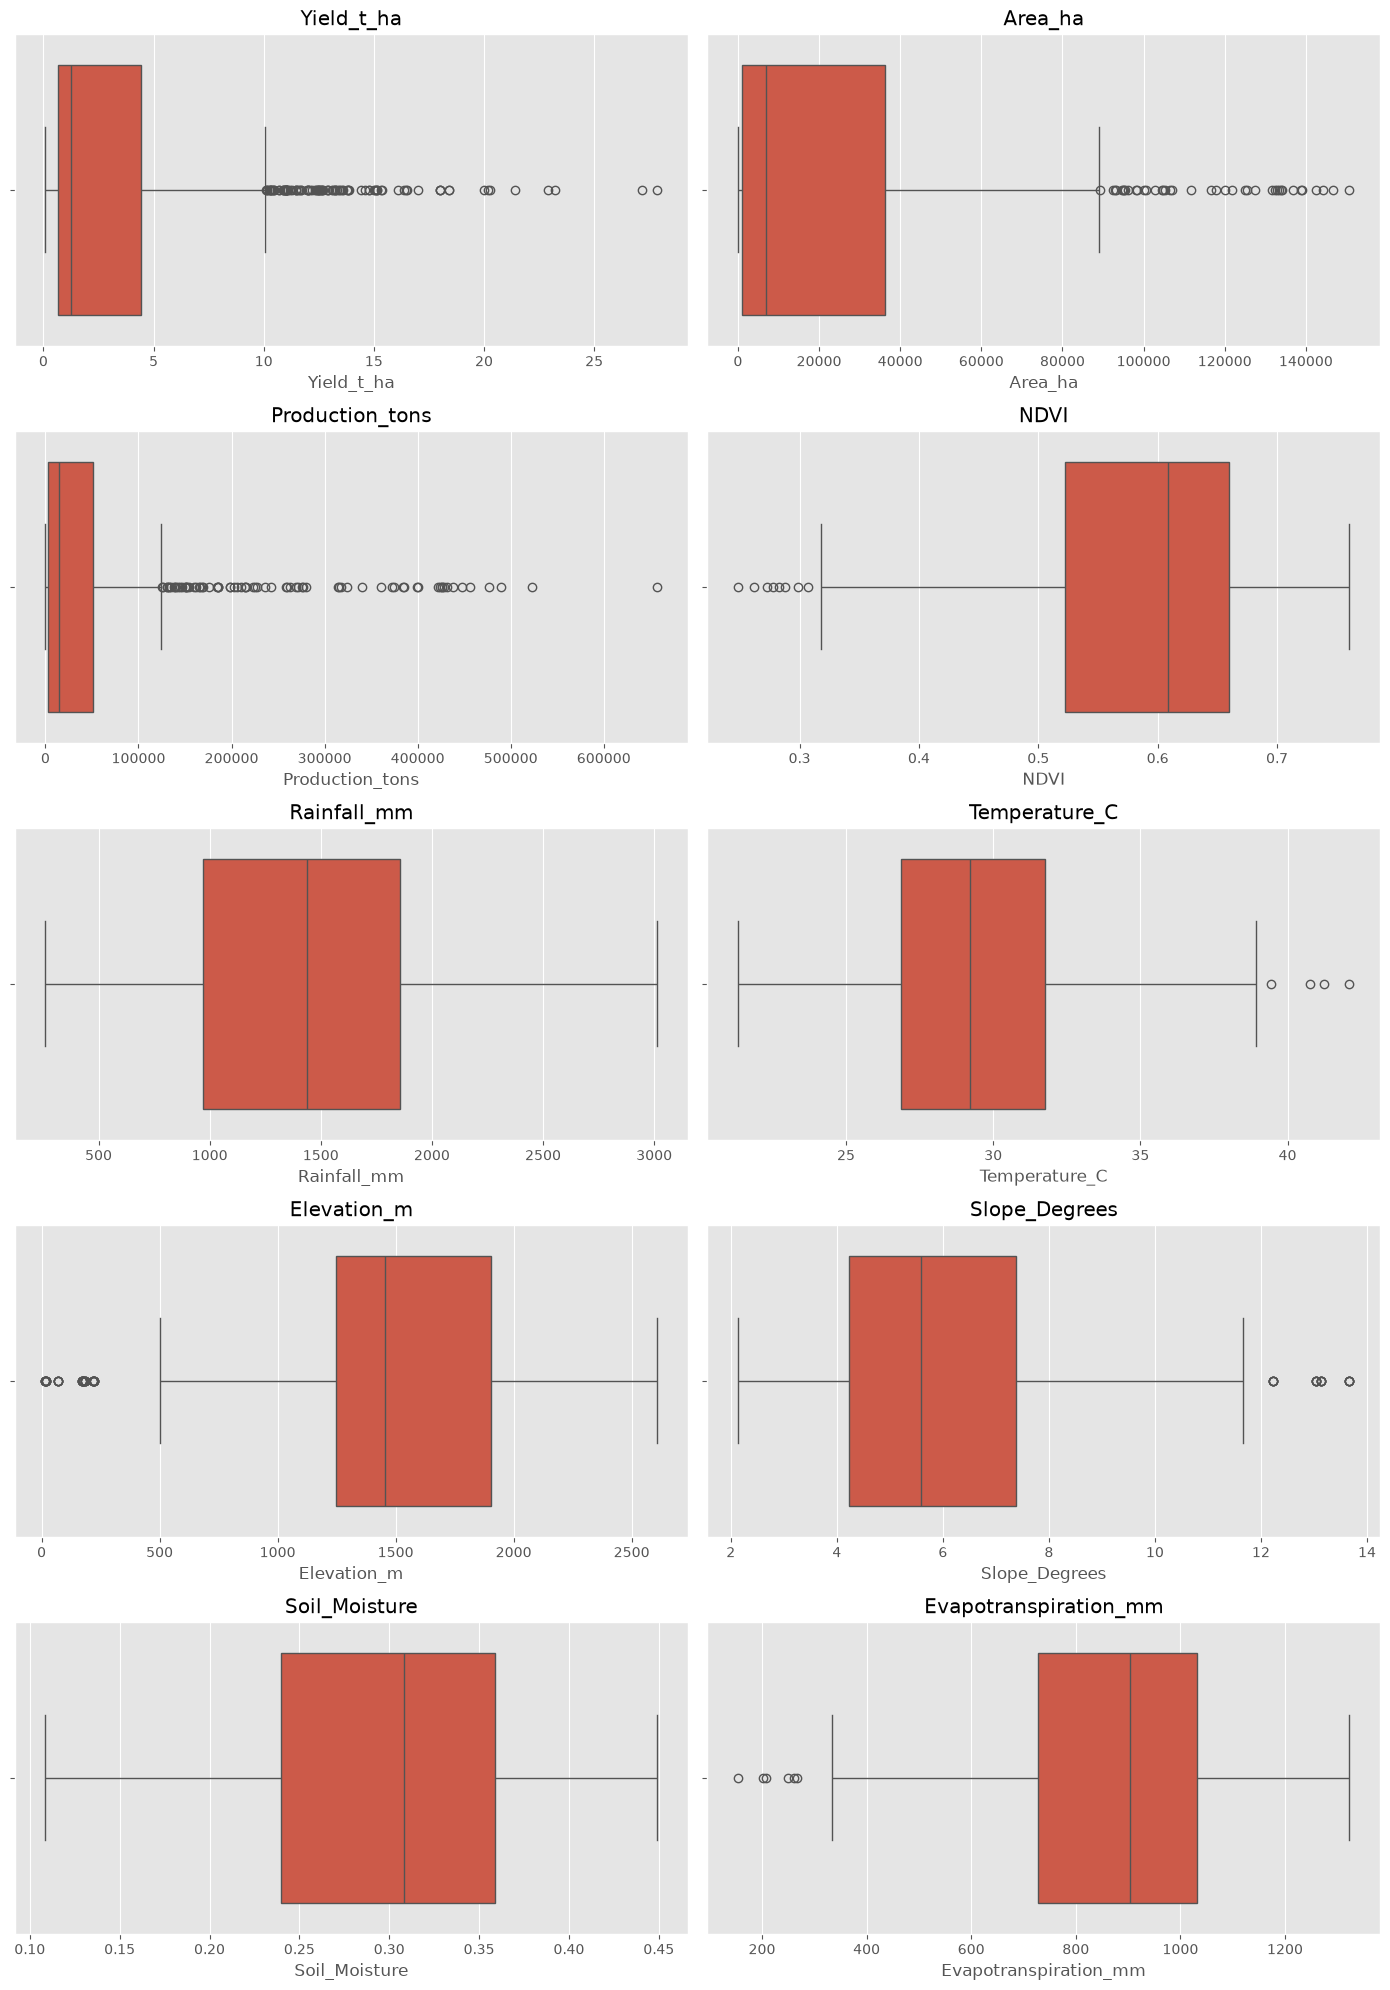

In [50]:
# Numerical variables
numerical_cols = [
    'Yield_t_ha',
    'Area_ha',
    'Production_tons',
    'NDVI',
    'Rainfall_mm',
    'Temperature_C',
    'Elevation_m',
    'Slope_Degrees',
    'Soil_Moisture',
    'Evapotranspiration_mm'
]

# Histograms
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()

plt.savefig(
    "../figures/numerical_variables_histograms.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Boxplots
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()

plt.savefig(
    "../figures/numerical_variables_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Distribution of Numerical Variables

The boxplots and histograms reveal the distribution and spread of the numerical variables in the dataset.

- **Yield (t/ha), Area (ha), and Production (tons)** are strongly right-skewed, with several high-value observations appearing as outliers. These extreme values are expected because crop production and cultivated area vary considerably across counties and crop types.

- **NDVI** is approximately normally distributed, with most observations ranging between 0.5 and 0.7, indicating moderate to healthy vegetation conditions across the study areas.

- **Rainfall** shows moderate variability, with values spanning approximately 300 mm to 3000 mm annually. The distribution is slightly skewed but does not contain many extreme outliers.

- **Temperature** is close to a normal distribution, with most counties recording annual average temperatures between 27°C and 32°C. Only a few high-temperature observations appear as outliers.

- **Elevation** exhibits a wide range, reflecting Kenya's diverse topography from low-lying coastal regions to highland areas.

- **Slope** is positively skewed, indicating that most agricultural areas occur on relatively gentle terrain, while a few counties contain steeper landscapes.

- **Soil Moisture** follows a fairly symmetric distribution centered around 0.30, suggesting moderate variation in moisture conditions.

- **Evapotranspiration** displays a near-normal distribution with moderate variability across counties and years.

Overall, the environmental variables (NDVI, rainfall, temperature, soil moisture, and evapotranspiration) exhibit relatively stable distributions, whereas the agricultural variables (yield, production, and cultivated area) contain substantial variability and several extreme values. These observations will be considered during data preprocessing and model development.

## Correlation Analysis

Correlation analysis was performed to examine the strength and direction of linear relationships among the numerical variables in the dataset. Understanding these relationships helps identify variables that may influence crop yield, detect potential multicollinearity among predictors, and provide insights for feature selection before model development.

Pearson's correlation coefficient, ranging from -1 to 1, was used to quantify the relationships between variables. Positive values indicate that two variables increase together, while negative values indicate that one variable decreases as the other increases.

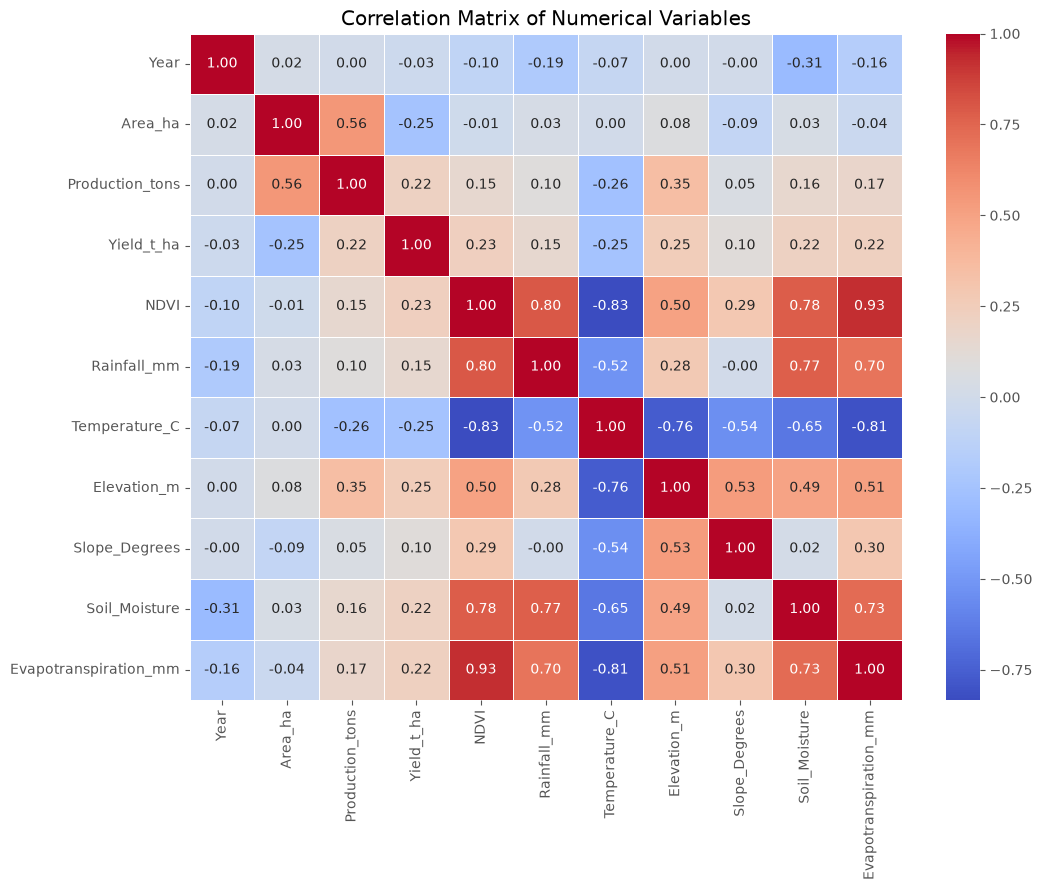

,Year,Area_ha,Production_tons,Yield_t_ha,NDVI,Rainfall_mm,Temperature_C,Elevation_m,Slope_Degrees,Soil_Moisture,Evapotranspiration_mm
Year,1.0000,0.0236,0.0006,-0.0301,-0.0968,-0.1899,-0.0682,0.0000,-0.0000,-0.3074,-0.1620
Area_ha,0.0236,1.0000,0.5556,-0.2484,-0.0134,0.0307,0.0000,0.0757,-0.0853,0.0338,-0.0418
Production_tons,0.0006,0.5556,1.0000,0.2171,0.1510,0.0962,-0.2633,0.3513,0.0493,0.1584,0.1711
Yield_t_ha,-0.0301,-0.2484,0.2171,1.0000,0.2263,0.1534,-0.2527,0.2547,0.1021,0.2188,0.2204
NDVI,-0.0968,-0.0134,0.1510,0.2263,1.0000,0.7967,-0.8339,0.5004,0.2854,0.7830,0.9265
Rainfall_mm,-0.1899,0.0307,0.0962,0.1534,0.7967,1.0000,-0.5196,0.2801,-0.0024,0.7708,0.6978
Temperature_C,-0.0682,0.0000,-0.2633,-0.2527,-0.8339,-0.5196,1.0000,-0.7649,-0.5444,-0.6489,-0.8112
Elevation_m,0.0000,0.0757,0.3513,0.2547,0.5004,0.2801,-0.7649,1.0000,0.5327,0.4940,0.5082
Slope_Degrees,-0.0000,-0.0853,0.0493,0.1021,0.2854,-0.0024,-0.5444,0.5327,1.0000,0.0172,0.2954
Soil_Moisture,-0.3074,0.0338,0.1584,0.2188,0.7830,0.7708,-0.6489,0.4940,0.0172,1.0000,0.7338


In [51]:
# Correlation Matrix

import os

# Numerical columns
numerical_cols = [
    'Year',
    'Area_ha',
    'Production_tons',
    'Yield_t_ha',
    'NDVI',
    'Rainfall_mm',
    'Temperature_C',
    'Elevation_m',
    'Slope_Degrees',
    'Soil_Moisture',
    'Evapotranspiration_mm'
]

# Compute correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(11,9))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()

# Save figure
os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/correlation_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

# Display correlation matrix
corr_matrix

## Correlation Analysis Interpretation

The correlation matrix shows the strength and direction of linear relationships between numerical variables.

Key observations include:

- Yield (Yield_t_ha) exhibits weak to moderate positive correlations with NDVI (0.23), Elevation (0.25), Soil Moisture (0.22), Evapotranspiration (0.22), and Production (0.22). These relationships suggest that improved vegetation condition, moisture availability, and favourable environmental conditions are associated with higher crop yields.

- Yield has a weak negative correlation with Temperature (-0.25), indicating that higher temperatures may reduce crop productivity. Yield also has a weak negative correlation with harvested area (-0.25), suggesting that larger cultivated areas do not necessarily produce higher yields per hectare.

- NDVI shows a very strong positive correlation with Evapotranspiration (0.93), a strong positive correlation with Rainfall (0.80), and a strong positive correlation with Soil Moisture (0.78). These relationships are expected because healthier vegetation generally occurs under adequate moisture conditions.

- Temperature is strongly negatively correlated with NDVI (-0.83), Evapotranspiration (-0.81), and Elevation (-0.76), indicating that cooler, higher-elevation regions tend to support healthier vegetation and greater moisture availability.

Overall, the environmental variables demonstrate logical relationships with one another. Although Yield_t_ha is not strongly correlated with any single predictor, this is expected because crop yield is influenced by multiple interacting factors. This supports the use of machine learning models capable of capturing nonlinear relationships among predictors.

## Crop-wise Yield Analysis

This analysis compares the distribution of crop yields across the eight crop types in the dataset.

Boxplots are used to examine differences in median yield, variability, and potential outliers among crops. Since each crop has unique biological characteristics and management practices, yield distributions are expected to differ considerably.

Understanding these differences helps identify high- and low-yielding crops and provides insights into crop-specific variability before model development.

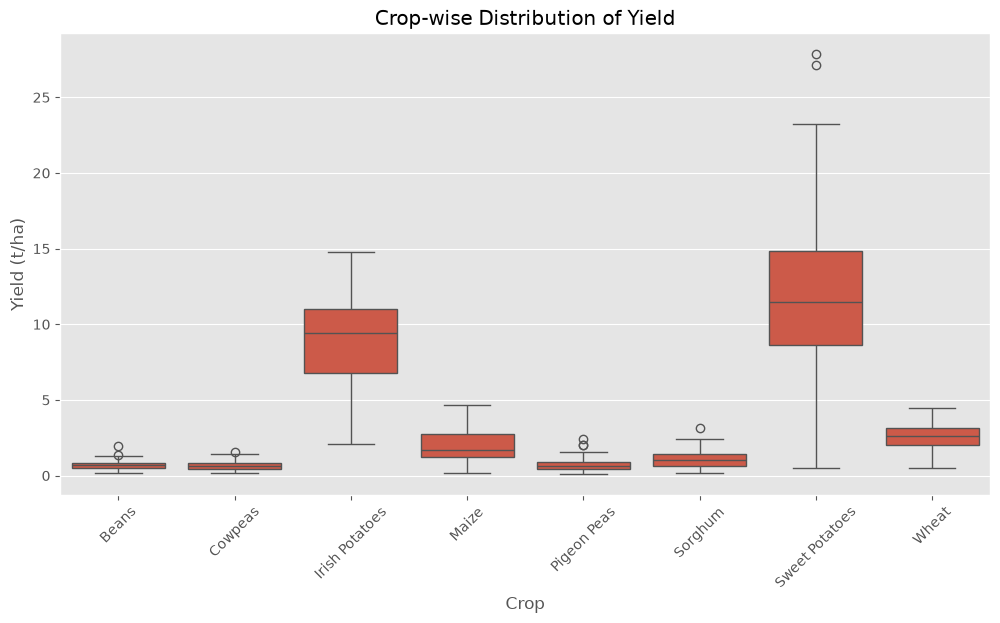

,count,mean,median,std,min,max
Crop,,,,,,
Beans,100,0.7000,0.6900,0.2700,0.1700,1.9700
Cowpeas,100,0.6700,0.6100,0.3000,0.2000,1.5600
Irish Potatoes,100,8.8200,9.4500,2.8500,2.1000,14.7600
Maize,100,1.9800,1.7000,1.0200,0.1700,4.6600
Pigeon Peas,87,0.7200,0.6700,0.4000,0.0900,2.4000
Sorghum,100,1.0900,1.0400,0.5300,0.1800,3.1500
Sweet Potatoes,100,11.9100,11.4600,5.0800,0.5100,27.8500
Wheat,70,2.5700,2.6400,0.9800,0.5000,4.5000


In [52]:
# Crop-wise Yield Analysis

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='Crop',
    y='Yield_t_ha'
)

plt.title('Crop-wise Distribution of Yield')
plt.xlabel('Crop')
plt.ylabel('Yield (t/ha)')
plt.xticks(rotation=45)

# Save figure
plt.savefig("../figures/cropwise_yield_boxplot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

# Summary statistics by crop
crop_summary = (
    df.groupby("Crop")["Yield_t_ha"]
      .agg(["count","mean","median","std","min","max"])
      .round(2)
)

display(crop_summary)

## Crop-wise Yield Analysis

This analysis compares the distribution of yield across the eight crop types using boxplots and summary statistics. It helps identify differences in productivity, variability, and potential outliers between crops.

### Interpretation
- Sweet potatoes recorded the highest average yield (11.91 t/ha), followed by Irish potatoes (8.82 t/ha). This is expected because root and tuber crops naturally produce much higher yields per hectare than cereal and legume crops.
- Wheat (2.57 t/ha) and maize (1.98 t/ha) had moderate yields, while beans (0.70 t/ha), cowpeas (0.67 t/ha), pigeon peas (0.72 t/ha), and sorghum (1.09 t/ha) recorded comparatively lower yields.
- Sweet potatoes exhibited the greatest variability (standard deviation = 5.08 t/ha), indicating considerable differences in productivity across counties and years. Irish potatoes also showed substantial variability (standard deviation = 2.85 t/ha).
- Several high-yield outliers are visible for sweet potatoes, while the remaining crops contain relatively few outliers. These observations are agriculturally plausible and were retained because they likely reflect genuine differences rather than data entry errors.
- The unequal number of observations for wheat (70) and pigeon peas (87), compared with 100 observations for most other crops, reflects differences in county-level production rather than missing records.

## Temporal (Yearly) Trends

This section examines how crop yield has changed over time by comparing the average yield for each year. The analysis helps identify overall trends, annual variability, and whether yields have generally increased or decreased during the study period.

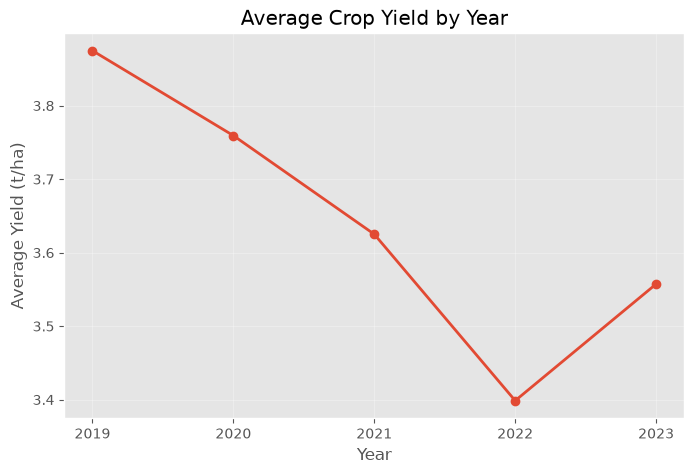

,Year,Yield_t_ha
0,2019,3.8700
1,2020,3.7600
2,2021,3.6300
3,2022,3.4000
4,2023,3.5600


In [53]:
# Average yield by year

yearly_yield = (
    df.groupby('Year')['Yield_t_ha']
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    yearly_yield['Year'],
    yearly_yield['Yield_t_ha'],
    marker='o',
    linewidth=2
)

plt.title('Average Crop Yield by Year')
plt.xlabel('Year')
plt.ylabel('Average Yield (t/ha)')
plt.xticks(yearly_yield['Year'])
plt.grid(alpha=0.3)

# Save figure
plt.savefig('../figures/yearly_yield_trend.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

display(yearly_yield.round(2))

## Temporal (Yearly) Trends Interpretation

The average crop yield showed a gradual decline from 3.87 t/ha in 2019 to 3.40 t/ha in 2022, before recovering slightly to 3.56 t/ha in 2023. Overall, the variation across years was relatively small, suggesting that there was no strong temporal trend in yield during the study period.

The slight decline between 2019 and 2022 may reflect the effects of varying weather conditions, particularly rainfall deficits and higher temperatures experienced in some years. The modest increase in 2023 indicates partial recovery in crop productivity. This observation is consistent with the correlation analysis, where Year exhibited a very weak negative correlation with yield (r = -0.03), indicating that year alone was not a strong predictor of crop yield.

## County-wise Trends

This analysis examines how crop yield varies across counties. Comparing the average yield by county helps identify high- and low-performing regions and reveals spatial differences in agricultural productivity.

The section includes:
- A horizontal bar chart showing the average yield for each county.
- Summary statistics of yield grouped by county.

These insights help determine whether geographic location contributes to variations in crop yield and can inform subsequent feature engineering and model development.

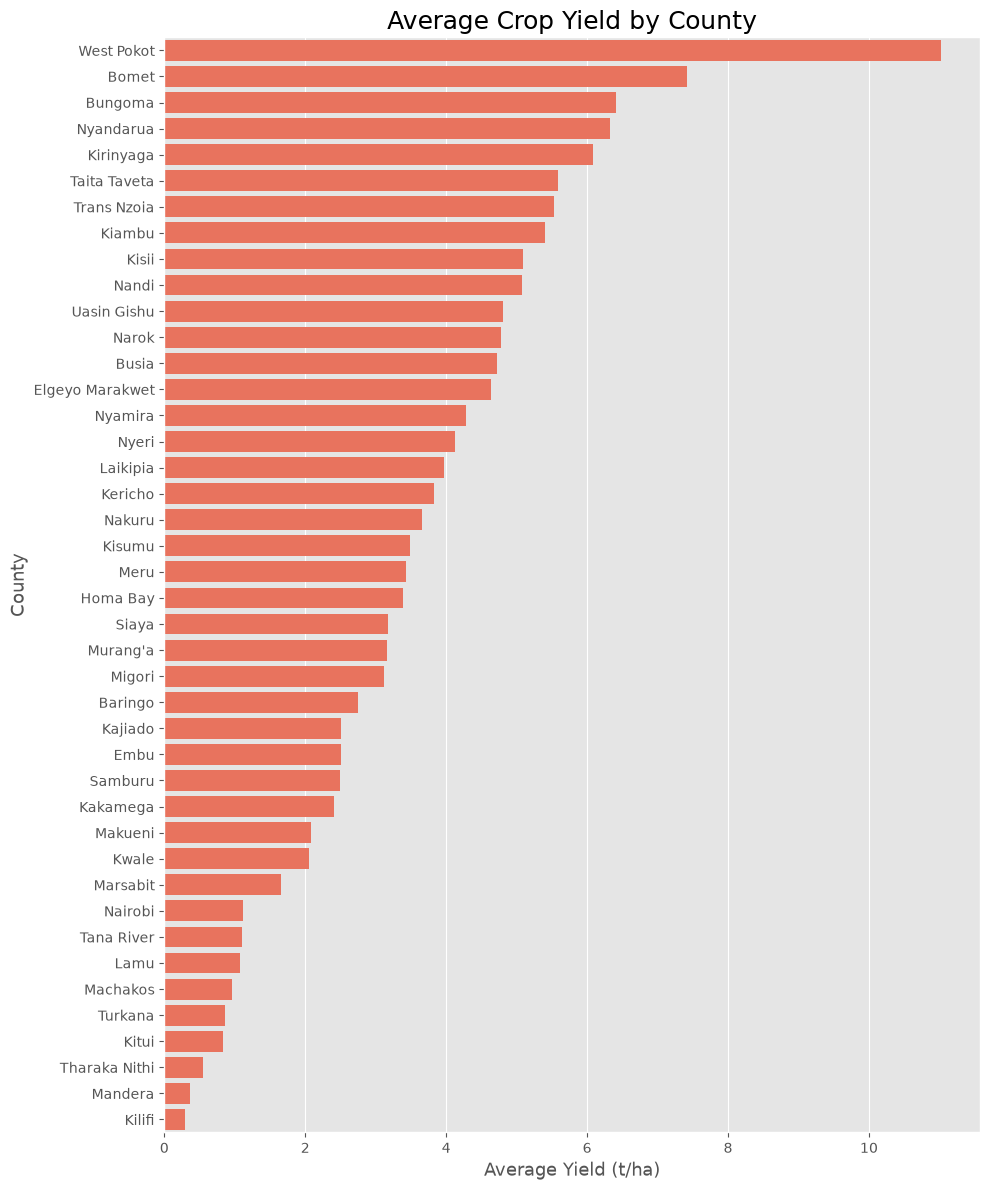

County-wise Yield Summary Statistics


,count,mean,median,std,min,max
County,,,,,,
West Pokot,5,11.0200,10.0000,2.4100,8.6800,14.7600
Bomet,20,7.4200,3.7900,7.1300,0.9600,20.2900
Bungoma,25,6.4100,3.1000,5.7100,0.5700,16.3500
Nyandarua,10,6.3300,4.2700,3.7500,2.8500,11.1100
Kirinyaga,15,6.0800,7.1200,4.8300,0.3200,12.5100
Taita Taveta,20,5.5800,0.6200,8.8900,0.0900,23.2300
Trans Nzoia,25,5.5300,3.8100,4.6300,0.3600,14.7800
Kiambu,15,5.4100,5.3400,3.7300,0.5500,11.2700
Kisii,15,5.0900,1.8200,5.8500,0.4800,15.3000


In [54]:
# County-wise average yield

county_yield = (
    df.groupby('County')['Yield_t_ha']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 12))

sns.barplot(
    data=county_yield,
    x='Yield_t_ha',
    y='County',
    color='tomato'
)

plt.title('Average Crop Yield by County', fontsize=18)
plt.xlabel('Average Yield (t/ha)', fontsize=13)
plt.ylabel('County', fontsize=13)

plt.tight_layout()

# Save figure
plt.savefig('../figures/countywise_average_yield.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

plt.show()

# Summary statistics by county
county_summary = (
    df.groupby('County')['Yield_t_ha']
      .agg(['count', 'mean', 'median', 'std', 'min', 'max'])
      .round(2)
      .sort_values('mean', ascending=False)
)

print("County-wise Yield Summary Statistics")
display(county_summary)

## Interpretation for Countywise Average Yield

The county-wise analysis reveals considerable spatial variation in average crop yields across Kenya. West Pokot recorded the highest average yield (11.02 t/ha), followed by Bomet (7.42 t/ha), Bungoma (6.41 t/ha), Nyandarua (6.33 t/ha), and Kirinyaga (6.08 t/ha). Conversely, Kilifi (0.29 t/ha), Mandera (0.37 t/ha), Tharaka Nithi (0.56 t/ha), Kitui (0.83 t/ha), and Turkana (0.86 t/ha) recorded the lowest average yields.

The summary statistics also show substantial variability in yield within several counties. For example, Bomet, Taita Taveta, Busia, Nyamira, and Narok have relatively large standard deviations and wide ranges between minimum and maximum yields, indicating considerable differences across crops and years.

These county averages should be interpreted with caution because the dataset combines multiple crop types with inherently different yield potentials. Counties cultivating high-yield crops such as Irish potatoes and sweet potatoes are expected to have higher average yields than counties dominated by cereals or legumes. Consequently, differences in county averages reflect not only environmental and management conditions but also variations in crop composition.

Overall, the analysis demonstrates that crop productivity varies considerably across Kenya, highlighting the influence of local environmental conditions, agricultural practices, and the mix of crops cultivated within each county.

## Save Cleaned Dataset

The cleaned dataset is saved to the `Processed_data` folder for use in the preprocessing, modelling, and evaluation stages. The original dataset remains unchanged in the `Raw_data` folder.

In [55]:
# Save cleaned dataset for the next stage of the project
df.to_csv(
    "../Data/Processed_data/Kenya_Crop_Yield_Processed.csv",
    index=False
)

print("Cleaned dataset saved successfully.")
print(f"Dataset Shape: {df.shape}")

Cleaned dataset saved successfully.
Dataset Shape: (757, 13)
